# Food Vision 101 Project 🍔🍕

In [ ]:
# Check GPU
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-45db0524-664e-4f23-d69b-8952e6d64bf1)


In [1]:
# Get helper functions
!wget https://raw.githubusercontent.com/Doyinakinloye/Helper_functions/refs/heads/main/Helper_functions.py


--2026-06-09 16:19:25--  https://raw.githubusercontent.com/Doyinakinloye/Helper_functions/refs/heads/main/Helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11537 (11K) [text/plain]
Saving to: ‘Helper_functions.py’

Helper_functions.py 100%[===================>]  11.27K  --.-KB/s    in 0.001s  

2026-06-09 16:19:25 (20.2 MB/s) - ‘Helper_functions.py’ saved [11537/11537]



In [2]:
from Helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys, list_class_names, plot_random_images, calculate_results

In [3]:
# Get data using TensorFlow Datasets
import tensorflow_datasets as tfds
datasets_lists = tfds.list_builders()
# Check if food101 is in dataset_lists
print("food101" in datasets_lists)

True


In [33]:
# Load in the data
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

In [ ]:
# Features of food101 from tsds
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [5]:
# get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
# The shape of our input data
ds_info.features["image"].shape

(None, None, 3)

In [ ]:
# data type of hte input data
ds_info.features["image"].tf_dtype

tf.uint8

Image shape: (512, 512, 3)
Image dtype: <dtype: 'uint8'>
Target class from Food101: spaghetti_bolognese
Minmum value in image tensor: 0
Maximum value in image tensor: 255


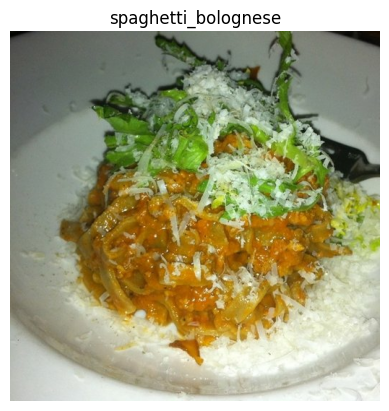

In [8]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Take a look at a sample of training data
for image, label in train_data.take(1):
    # print the image shape, data type and class name
    print(f"Image shape: {image.shape}")
    print(f"Image dtype: {image.dtype}")
    print(f"Target class from Food101: {class_names[label.numpy()]}")
    # get the minimum and maximum value of our image tensor
    print(f"Minmum value in image tensor: {tf.reduce_min(image).numpy()}")
    print(f"Maximum value in image tensor: {tf.reduce_max(image).numpy()}")
    # plot the image
    plt.imshow(image)
    # Add the image label as the title
    plt.title(class_names[label.numpy()])
    # remove the axis
    plt.axis(False)

### Create pre-processing functions for our datasets

In [11]:
import tensorflow as tf

def pre_process_img(image, label, img_shape=224, scale=False, augment=False):
  """Pre-processes (resizes, optionally scales, and augments) the input data into data ready for modelling.
  Returns pre-processed image along sides their labels.

  Args:
  image, label: image and its label in a tuple format.
  img_shape: The scale to which the image should be resized to.
  scale: If true, the image would be scaled by 1/255.0. (Typically set to False for EfficientNet models due to internal scaling).
  augment: If true, apply data augmentation to the image (e.g., random flip, brightness, contrast).
  """
  image = tf.image.resize(image, [img_shape, img_shape])
  image = tf.cast(image, tf.float32) # Cast to float32 before augmentations that require it

  if augment:
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2) # Adjust brightness randomly
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2) # Adjust contrast randomly

  if scale:
    image = image/255.0

  return image, label

In [10]:
# Map preprocessing function to training
train_data = train_data.map(map_func=pre_process_img, num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train data and turn it into batches and prefetch it(load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

In [34]:
# Map preprocessing function to test data
test_data = test_data.map(map_func=pre_process_img, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

### Create modelling callbacks

In [ ]:
# create a model checkpoint callback and save model progress during training
checkpoint_path = "model_checkpoint/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_acc",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      mode="max")

### Set up mixed precision training

In [6]:
# turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16") # set global data policy to mixed precision

In [ ]:
!nvidia-smi

Mon May 18 21:00:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             31W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

### Feature extraction
Using the efficientNetB0 model

In [ ]:
# data augmentation layer using sequential model
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
    tf.keras.layers.GaussianNoise(0.05)
], name="data_augmentation")

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB0

# Create a base model (EfficientNetB0 with pre-trained weights, excluding the top classification layer)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
# Freeze the base model layers so they are not updated during training
base_model.trainable = False

# Create an input layer with the specified shape (224x224, no channel dimension yet, Keras will infer it)
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")

# add a data augmentation
# x = data_augmentation(inputs)

# Apply the base model to the input layer (passing training=False to keep batch norm statistics fixed)
x = base_model(inputs, training=False)

# Add a GlobalAveragePooling2D layer to reduce the spatial dimensions to 1x1
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Add the output dense layer with the number of classes and no activation (activation will be handled separately)
x = layers.Dense(len(class_names), name="output_layer")(x)

# Add a softmax activation layer, ensuring outputs are in float32 for mixed precision compatibility
outputs = layers.Activation("softmax", dtype=tf.float32, name="activation_layer")(x)

# Create the functional API model by specifying inputs and outputs
model = tf.keras.Model(inputs, outputs)

In [ ]:
# compile the model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [ ]:
# check the dtype policy for each layer
for layer_no, layer in enumerate(model.layers):
  print(layer_no, layer.name, layer.dtype, layer.dtype_policy, layer.name)

0 input_layer float32 <DTypePolicy "mixed_float16"> input_layer
1 efficientnetb4 float32 <DTypePolicy "mixed_float16"> efficientnetb4
2 global_average_pooling_layer float32 <DTypePolicy "mixed_float16"> global_average_pooling_layer
3 dense_1 float32 <DTypePolicy "mixed_float16"> dense_1
4 dropout_1 float32 <DTypePolicy "mixed_float16"> dropout_1
5 output_layer float32 <DTypePolicy "mixed_float16"> output_layer
6 activation_layer float32 <DTypePolicy "float32"> activation_layer


In [ ]:
# Iterate through each layer in the base model and print its layer number, name, and dtype policy.
for layer_no, layer in enumerate(base_model.layers):
  print(layer_no, layer.name, layer.dtype_policy)

0 input_layer_1 <DTypePolicy "mixed_float16">
1 rescaling_2 <DTypePolicy "mixed_float16">
2 normalization_1 <DTypePolicy "mixed_float16">
3 rescaling_3 <DTypePolicy "mixed_float16">
4 stem_conv_pad <DTypePolicy "mixed_float16">
5 stem_conv <DTypePolicy "mixed_float16">
6 stem_bn <DTypePolicy "mixed_float16">
7 stem_activation <DTypePolicy "mixed_float16">
8 block1a_dwconv <DTypePolicy "mixed_float16">
9 block1a_bn <DTypePolicy "mixed_float16">
10 block1a_activation <DTypePolicy "mixed_float16">
11 block1a_se_squeeze <DTypePolicy "mixed_float16">
12 block1a_se_reshape <DTypePolicy "mixed_float16">
13 block1a_se_reduce <DTypePolicy "mixed_float16">
14 block1a_se_expand <DTypePolicy "mixed_float16">
15 block1a_se_excite <DTypePolicy "mixed_float16">
16 block1a_project_conv <DTypePolicy "mixed_float16">
17 block1a_project_bn <DTypePolicy "mixed_float16">
18 block1b_dwconv <DTypePolicy "mixed_float16">
19 block1b_bn <DTypePolicy "mixed_float16">
20 block1b_activation <DTypePolicy "mixed_flo

In [ ]:
# fit the model
history_feature_extraction = model.fit(train_data,
                                        epochs=5,
                                        steps_per_epoch=int(len(train_data)),
                                        validation_data=test_data,
                                        validation_steps=int(0.15 * len(test_data)),
                                        callbacks=[model_checkpoint, create_tensorboard_callback("TensorBoard", "Model_experiment_1")])

Saving TensorBoard log files to: TensorBoard/Model_experiment_1/20260609-082710
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4711 - loss: 2.2987

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 327s 109ms/step - accuracy: 0.5625 - loss: 1.7947 - val_accuracy: 0.6923 - val_loss: 1.1332
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 195s 81ms/step - accuracy: 0.6651 - loss: 1.2911 - val_accuracy: 0.7174 - val_loss: 1.0442
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 193s 81ms/step - accuracy: 0.6959 - loss: 1.1591 - val_accuracy: 0.7256 - val_loss: 0.9925
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 192s 80ms/step - accuracy: 0.7161 - loss: 1.0752 - val_accuracy: 0.7299 - val_loss: 0.9869
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 192s 80ms/step - accuracy: 0.7287 - loss: 1.0161 - val_accuracy: 0.7365 - val_loss: 0.9609


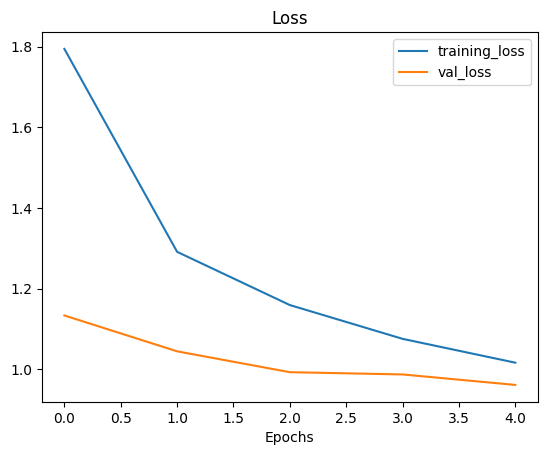

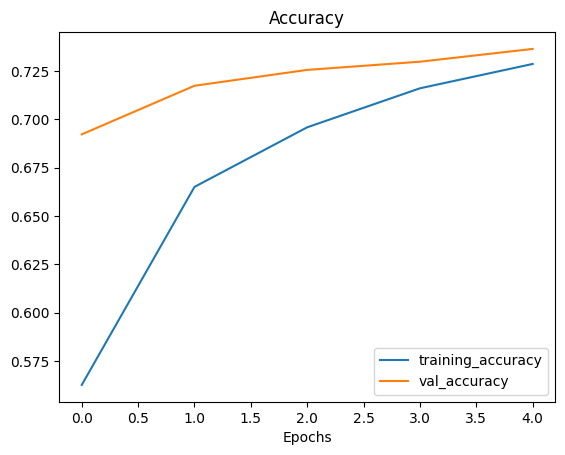

In [ ]:
plot_loss_curves(history_feature_extraction)

In [ ]:
model.save("drive/MyDrive/models/101_food_classes_full_feature_extraction_model1.keras")

In [ ]:
feature_extraction_evaluation = model.evaluate(test_data)
feature_extraction_evaluation

790/790 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.7346 - loss: 0.9657


[0.9656772613525391, 0.734613835811615]

In [ ]:
# load saved model
loaded_model = tf.keras.models.load_model("drive/MyDrive/models/101_food_classes_full_feature_extraction_model1.keras")

In [ ]:
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_layer (Activation)   │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,437,720 (16.93 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 258,768 (1010.82 KB)

### Fine tuning our feature extraction model

In [ ]:
import tensorflow as tf

# Get the base model (EfficientNetB4) from the loaded_model
base_model_layer = loaded_model.layers[1]

# Unfreeze the base model layer itself (this makes its internal layers trainable if they are not already)
base_model_layer.trainable = True

# Freeze all layers within the base_model_layer except the last 20
for layer in base_model_layer.layers[:-20]:
  layer.trainable = False

In [ ]:
# Compile the model again
loaded_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=["accuracy"])

In [ ]:
# create a new checkpoint path for the model checkpoint
checkpoint_path = "model_checkpoint_2/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_acc",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      mode="max")

In [ ]:
# Fit the fine-tuned model
history_fine_tuning = loaded_model.fit(train_data,
          epochs= 10,
          steps_per_epoch=len(train_data),
          validation_data=test_data,
          initial_epoch= 5,
          validation_steps=int(0.15 * len(test_data)),
          callbacks=[model_checkpoint, create_tensorboard_callback("TensorBoard", "Model_experiment_2")])

Saving TensorBoard log files to: TensorBoard/Model_experiment_2/20260609-084931
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 299s 102ms/step - accuracy: 0.7119 - loss: 1.0842 - val_accuracy: 0.7619 - val_loss: 0.8611
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 201s 84ms/step - accuracy: 0.7718 - loss: 0.8436 - val_accuracy: 0.7802 - val_loss: 0.8092
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 201s 84ms/step - accuracy: 0.8008 - loss: 0.7308 - val_accuracy: 0.7818 - val_loss: 0.7915
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 198s 82ms/step - accuracy: 0.8245 - loss: 0.6450 - val_accuracy: 0.7805 - val_loss: 0.7879
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 194s 81ms/step - accuracy: 0.8438 - loss: 0.5764 - val_accuracy: 0.7910 - val_loss: 0.7718


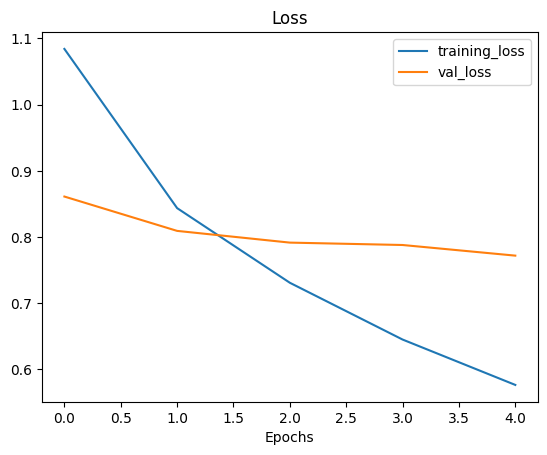

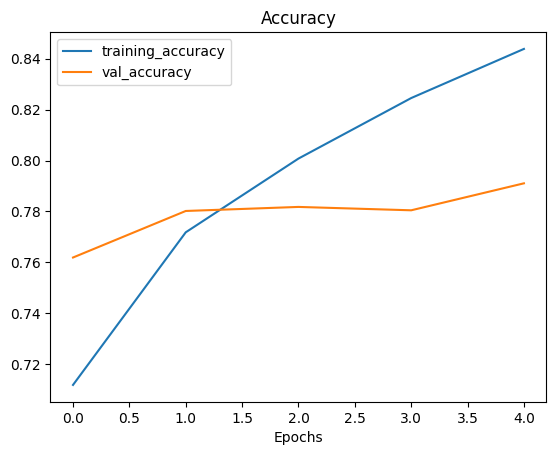

In [ ]:
# plot the loss curve of our fine tuned model
plot_loss_curves(history_fine_tuning)

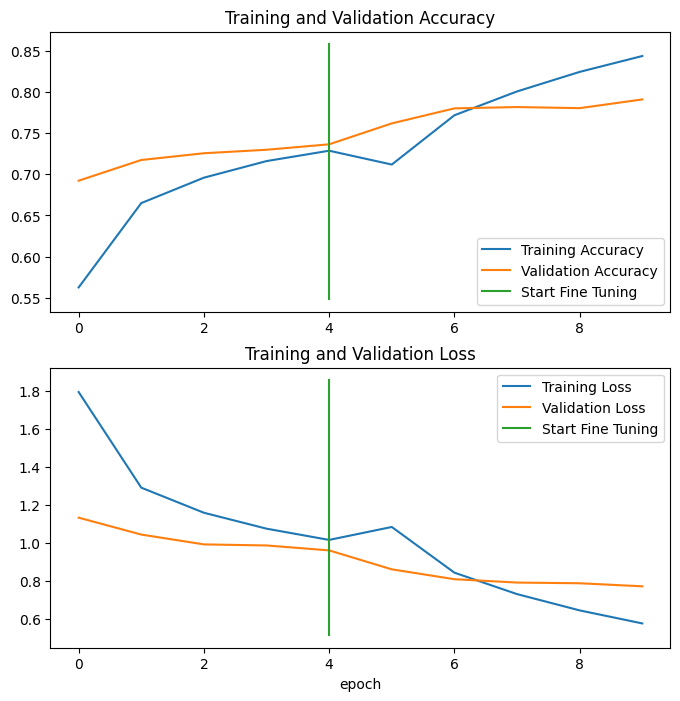

In [ ]:
compare_historys(history_feature_extraction, history_fine_tuning)

In [ ]:
# save fine tuned model
loaded_model.save("drive/MyDrive/models/101_food_classes_full_fine_tuned_model1.keras")

In [20]:
# load the saved model
import tensorflow as tf
loaded_model = tf.keras.models.load_model("drive/MyDrive/models/101_food_classes_full_fine_tuned_model1.keras")

In [ ]:
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_layer (Activation)   │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,139,640 (27.24 MB)

 Trainable params: 1,480,341 (5.65 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

 Optimizer params: 2,960,688 (11.29 MB)

### Evaluate the fine-tuned model

In [37]:
import numpy as np

# Initialize lists to store true and predicted labels in order
y_true_aligned = []
y_pred_aligned = []

# Iterate through the test_data dataset to get true labels and make predictions
for images, labels in test_data:
    # Collect true labels
    y_true_aligned.extend(labels.numpy())

    # Make predictions and get predicted class indices
    predictions = loaded_model.predict(images, verbose=0) # verbose=0 to suppress per-batch output
    y_pred_aligned.extend(np.argmax(predictions, axis=1))

print(f"Length of y_true_aligned: {len(y_true_aligned)}")
print(f"Length of y_pred_aligned: {len(y_pred_aligned)}")


Length of y_true_aligned: 25250
Length of y_pred_aligned: 25250


In [38]:
from sklearn.metrics import classification_report, accuracy_score

# Calculate and print the classification report with aligned labels
print("Corrected Classification Report:")
print(classification_report(y_true_aligned, y_pred_aligned, target_names=class_names, zero_division=0))

# Calculate and print the accuracy score with aligned labels
corrected_accuracy = accuracy_score(y_true_aligned, y_pred_aligned)
print(f"Corrected Accuracy Score: {corrected_accuracy:.4f}")

# Compare with the model.evaluate accuracy
model_eval_accuracy = fine_tuning_evaluation[1]
print(f"Model.evaluate Accuracy: {model_eval_accuracy:.4f}")


Corrected Classification Report:
                         precision    recall  f1-score   support

              apple_pie       0.60      0.60      0.60       250
         baby_back_ribs       0.75      0.79      0.77       250
                baklava       0.87      0.82      0.84       250
         beef_carpaccio       0.74      0.83      0.78       250
           beef_tartare       0.64      0.70      0.67       250
             beet_salad       0.59      0.75      0.66       250
               beignets       0.83      0.87      0.85       250
               bibimbap       0.87      0.92      0.89       250
          bread_pudding       0.68      0.56      0.62       250
      breakfast_burrito       0.73      0.70      0.71       250
             bruschetta       0.75      0.66      0.70       250
           caesar_salad       0.82      0.84      0.83       250
                cannoli       0.85      0.83      0.84       250
          caprese_salad       0.75      0.79      0.77  

In [40]:
import numpy as np
class_names[np.argmax(y_pred_aligned[0])]

'apple_pie'

### Plot confusion Matrix

In [42]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels
         )

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # change the rotation of the xticks
  plt.xticks(rotation=70)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

In [43]:
make_confusion_matrix(y_true=y_true_aligned,
                      y_pred=y_pred_aligned,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=10)

In [44]:
calculate_results(y_true_aligned, y_pred_aligned)

{'accuracy': 78.82376237623762,
 'precision': 0.7887632682201835,
 'recall': 0.7882376237623763,
 'f1': 0.7872119837130694}